In [45]:
import boto3
import os
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt


inspection_id = "0A49KLT3B7Y" #fhr8
angle_profiles = ["0"]
num_tracks = 22
run_number = 8

In [46]:
def download_s3_folder(bucket_name: str, s3_folder: str, local_dir: str = None):
    """
    Download the contents of a folder directory
    Args:
        bucket_name: the name of the s3 bucket
        s3_folder: the folder path in the s3 bucket
        local_dir: the dir data is downloaded to
    """
    s3 = boto3.resource("s3")
    bucket = s3.Bucket(bucket_name)
    for obj in bucket.objects.filter(Prefix=s3_folder):
        target = (
            obj.key
            if local_dir is None
            else os.path.join(local_dir, os.path.relpath(obj.key, s3_folder))
        )
        if not os.path.exists(os.path.dirname(target)):
            os.makedirs(os.path.dirname(target))
        if obj.key[-1] == "/":
            continue
        if not os.path.exists(target):
            bucket.download_file(obj.key, target)
            print("Downloading: {}".format(obj.key))

results_dir = f"./data-files/insp_{inspection_id}_dent_detection_ae_rerun"
if not os.path.exists(results_dir):
    os.makedirs(results_dir)
download_s3_folder("dv-ilit0008", f"track_reruns/{inspection_id}/dent_detection_ae/", results_dir)

In [47]:
root = Path(results_dir)
data_files = sorted(root.rglob("*.parquet"))

In [48]:
len(data_files), data_files

(27,
 [PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000000000.0_0000001000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000001000.0_0000002000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000002000.0_0000003000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000003000.0_0000004000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000004000.0_0000005000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000005000.0_0000006000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('data-files/insp_0A49KLT3B7Y_dent_detection_ae_rerun/distance_0000006000.0_0000007000.0_framestep_000001_margin_0.15.parquet'),
  PosixPath('da

In [49]:
pd.read_csv(data_files[7])

,start,end,prob
0,6999.85,7000.15,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
1,7000.00,7000.30,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
2,7000.15,7000.45,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
3,7000.30,7000.60,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
4,7000.45,7000.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
...,...,...,...
6664,7999.45,7999.75,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6665,7999.60,7999.90,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6666,7999.75,8000.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."
6667,7999.90,8000.20,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ..."


In [40]:
## Create a DataFrame for each profile and track and range
def create_df(frame_range=None):
    if frame_range is None:
        data_files_range = [f for f in data_files]
    else:
        data_files_range = [f for f in data_files if f.name.startswith(f"frames_{frame_range[0]:012d}_{frame_range[1]:012d}")]


    dfs = []
    for path in data_files_range:
        df = pd.read_csv(path)
        dfs.append(df)

        # Handle case where all DataFrames were empty or had errors
    if not dfs:
        print(f"No valid data found for frame_range={frame_range}")
        return pd.DataFrame()
    
    return pd.concat(dfs) if len(dfs) > 1 else dfs[0]

Threshold 0.050: 453/175430 passed (453/175430 positives, 0.2582%)
Threshold 0.400: 254/175430 passed (254/175430 positives, 0.1448%)
Threshold 0.500: 232/175430 passed (232/175430 positives, 0.1322%)
Threshold 0.600: 212/175430 passed (212/175430 positives, 0.1208%)
Threshold 0.700: 191/175430 passed (191/175430 positives, 0.1089%)
Threshold 0.800: 164/175430 passed (164/175430 positives, 0.0935%)
DbHealthCheck.cpp(146): Database service health check complete: Healthy
Threshold 0.900: 126/175430 passed (126/175430 positives, 0.0718%)
Threshold 0.970: 84/175430 passed (84/175430 positives, 0.0479%)
Threshold 0.990: 54/175430 passed (54/175430 positives, 0.0308%)


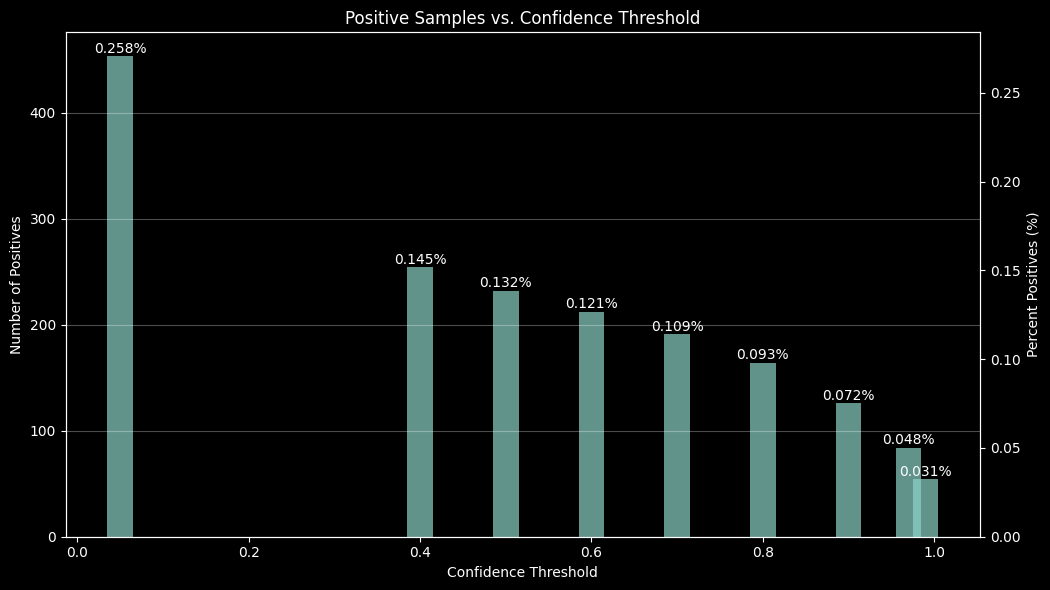

In [41]:
# Assuming all_dfs is your dataframe with columns: start, end, and prob
import ast

# Function to parse probability strings into actual lists if needed
def parse_prob(prob_str):
    """Convert string representation of list to actual list if needed"""
    if isinstance(prob_str, str):
        try:
            return ast.literal_eval(prob_str)
        except:
            return []
    return prob_str

# Process each threshold
thresholds = [0.05,0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.97, 0.99]
results = []
all_dfs = create_df()

for threshold in thresholds:
    # Lists to store entries that pass the threshold
    filtered_entries = []
    total_samples = len(all_dfs)
    num_positives = 0
    
    # Process each row
    for i, row in all_dfs.iterrows():
        # Parse the probability values if needed
        probs = parse_prob(row['prob'])
        
        # Check if any probability exceeds the threshold
        if any(p >= threshold for p in probs):
            # Add this entry to our filtered list
            filtered_entries.append({
                'start': row['start'],
                'end': row['end'],
                'prob': probs,
                'max_prob': max(probs)
            })
            num_positives += 1
    
    # Store results for this threshold
    results.append({
        'threshold': threshold,
        'filtered_entries': filtered_entries,
        'num_positives': num_positives,
        'total': total_samples,
        'num_positives_percent': (num_positives / total_samples) * 100 if total_samples > 0 else 0
    })
    print(f"Threshold {threshold:.3f}: {len(filtered_entries)}/{total_samples} passed "
          f"({num_positives}/{total_samples} positives, {num_positives/total_samples:.4%})")

# Plotting the results
plt.style.use('dark_background')
plt.figure(figsize=(10, 6))

# Extract data for plotting
thresholds = [r['threshold'] for r in results]
num_positives_counts = [r['num_positives'] for r in results]
num_positives_percent = [r['num_positives_percent'] for r in results]

# Create bar plot
bars = plt.bar(thresholds, num_positives_counts, width=0.03, alpha=0.7)

# Add percentage labels on top of bars
for bar, percent in zip(bars, num_positives_percent):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height + 0.5,
             f'{percent:.3f}%', ha='center', va='bottom')


# Add labels and title
plt.xlabel('Confidence Threshold')
plt.ylabel('Number of Positives')
plt.title('Positive Samples vs. Confidence Threshold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()

# Add second y-axis for percentage
ax2 = plt.gca().twinx()
ax2.set_ylabel('Percent Positives (%)')
ax2.plot(thresholds, num_positives_percent, 'r-', alpha=0)  # Invisible, just for scale
ax2.set_ylim(0, max(num_positives_percent) * 1.1)

plt.show()

In [42]:
# Access filtered entries for threshold 0.9
entries_09 = results[0]['filtered_entries']  # Index 5 corresponds to threshold 0.9
print(f"Found {len(entries_09)} entries")

# Optional: Create a new DataFrame with filtered entries
import pandas as pd
filtered_df = pd.DataFrame(entries_09)
display(filtered_df)

Found 453 entries


,start,end,prob,max_prob
0,1.05,1.35,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, ...",0.1082
1,1.20,1.50,"[0.0001, 0.0002, 0.0, 0.0001, 0.0001, 0.0, 0.0...",0.2103
2,1.50,1.80,"[0.0001, 0.0001, 0.0, 0.0003, 0.0001, 0.0001, ...",0.3292
3,1.80,2.10,"[0.0083, 0.0217, 0.0015, 0.0076, 0.0009, 0.000...",0.7995
4,1.95,2.25,"[0.0002, 0.0013, 0.0001, 0.001, 0.0001, 0.0001...",0.6342
...,...,...,...,...
448,26303.45,26303.75,"[0.0, 0.0, 0.0, 0.0001, 0.0009, 0.2915, 0.7475...",0.7475
449,26303.60,26303.90,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0396, 0.9335, 0.0,...",0.9335
450,26303.75,26304.05,"[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0002, 0.0, 0....",0.8182
451,26303.90,26304.20,"[0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0,...",0.9942


In [43]:
def filter_close_detections(df, distance_threshold=0.2):
    """
    Filter out detections that are close to each other.
    When multiple detections are within distance_threshold, keep only the one with larger start value.
    
    Args:
        df: DataFrame with 'start' column
        distance_threshold: Maximum allowed distance between starts (default 0.2)
        
    Returns:
        DataFrame with filtered rows
    """
    if len(df) <= 1:
        return df
    
    # Sort by start column in descending order (larger values first)
    df_sorted = df.sort_values(by='start', ascending=False).reset_index(drop=True)
    
    # Initialize with first row (largest start value)
    kept_indices = [0]
    last_kept_start = df_sorted.loc[0, 'start']
    
    # Process remaining rows
    for i in range(1, len(df_sorted)):
        current_start = df_sorted.loc[i, 'start']
        
        # If far enough from last kept row, keep this one too
        # Note: Since we're going from larger to smaller, the comparison is flipped
        if last_kept_start - current_start >= distance_threshold:
            kept_indices.append(i)
            last_kept_start = current_start
    
    # Return dataframe with only kept rows
    return df_sorted.loc[kept_indices].reset_index(drop=True)

# Example usage
filtered_df_deduped = filter_close_detections(filtered_df)
print(f"Original detections: {len(filtered_df)}")
print(f"After deduplication: {len(filtered_df_deduped)}")

Original detections: 453
After deduplication: 358


In [44]:
import sys
import os

# Add parent directory to path (adjust as needed)
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.append(project_root)
    print(f"Added {project_root} to Python path")
    
from rnd.utils.data_utils import (
    extract_arm_angles,
    create_arm_array,
)
from ilipy import Session
from ilipy.database import DistanceCorrelation

root_dir = f"./data/fhr{run_number}"
os.makedirs(root_dir, exist_ok=True)

session = Session(environment="prod")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)

def gen_image(img_start, session, dist_corr, length= 0.3, show_im=True, normalize="range"):
    img_range = (img_start, img_start + length)
    tick_sampling_interval = 10

    arm_angles = extract_arm_angles(session, dist_corr, img_range, tick_sampling_interval=tick_sampling_interval)
    num_tick_samples = int(length * 10000 / tick_sampling_interval)
    img = create_arm_array(
    arm_angles,
    num_tracks=num_tracks,
    num_tick_samples=num_tick_samples,
    normalize=normalize,
)
    if show_im: 
        plt.imshow(
            img.T, cmap="inferno", origin="lower", aspect="auto",
            interpolation="nearest",
        )

        plt.axis("off")
        plt.colorbar()
        plt.show()
    return img


PyAuthenticator.cpp(239): Attempting an IAM role login as no username and password or environment variables were provided.
CognitoAuthenticator.cpp(158): Using Cognito Credentials
CognitoAuthenticator.cpp(919): Error refreshing Tokens: Refresh Token has expired
CognitoAuthenticator.cpp(162): Unable to login with Cognito. Please re-login using a valid Cognito User


RuntimeError: Failed to authenticate with IAM role, if you wish to use Cognito Environment variables, set DV_COGNITO_USERNAME and DV_COGNITO_PASSWORD in the environment or pass a valid username and password to the authentication function.

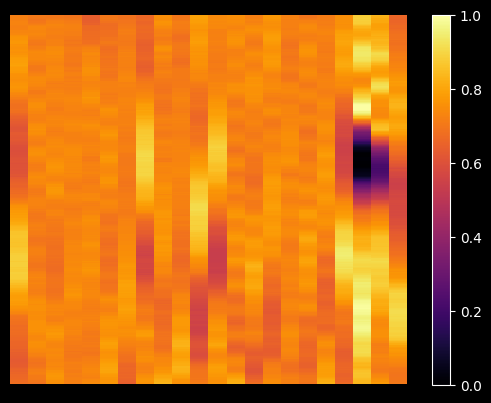

DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: Healthy
DbHealthCheck.cpp(146): Database service health check complete: 

In [ ]:
img_std = gen_image(7984.89, session, dist_corr, length=0.3, show_im=True, normalize="std")

In [ ]:
for i, row in filtered_df_deduped.iterrows():
    vd = (row['start']+ row['end'])/2
    # img_std = gen_image(row['start'], session, dist_corr, length=0.3, show_im=True, normalize="std")

    print(vd, row['prob'])

26304.650000002955 [0.0, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.003, 0.0, 0.0001, 0.9355, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
26304.05000000295 [0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0001, 0.0, 0.0049, 0.9942, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
26303.750000002947 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0396, 0.9335, 0.0, 0.0, 0.0001, 0.0, 0.0002, 0.0003, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0]
26303.000000002936 [0.0001, 0.0014, 0.0873, 0.0009, 0.0003, 0.0008, 0.0003, 0.0015, 0.0001, 0.0002, 0.0003, 0.0, 0.0005, 0.0013, 0.0003, 0.0006, 0.0003, 0.0021, 0.8235, 0.0686, 0.5, 0.5]
26302.40000000293 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0011, 0.9783, 0.0006, 0.0, 0.0, 0.0]
26302.10000000293 [0.0, 0.0, 0.0, 0.0001, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0004, 0.0, 0.0, 0.0001, 0.0, 0.0037, 0.9308, 0.0002, 0.0, 0.0, 0.0]
26296.85000000288 [0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0

In [ ]:
import boto3
import pandas as pd
from io import BytesIO

def save_df_to_s3_parquet(df, bucket_name, s3_key):
    """
    Save DataFrame to S3 as parquet file
    
    Args:
        df: DataFrame to save
        bucket_name: S3 bucket name
        s3_key: S3 key (path) for the file
    """
    # Convert DataFrame to parquet in memory
    parquet_buffer = BytesIO()
    df.to_parquet(parquet_buffer, index=False)
    parquet_buffer.seek(0)
    
    # Upload to S3
    s3_client = boto3.client('s3')
    s3_client.put_object(
        Bucket=bucket_name,
        Key=s3_key,
        Body=parquet_buffer.getvalue(),
        ContentType='application/octet-stream'
    )
    
    print(f"DataFrame saved to s3://{bucket_name}/{s3_key}")
bucket_name = "dent-dev"
s3_key = f"dent_bookmarks/ArmDent_bookmarks_{inspection_id}.parquet"
#save_df_to_s3_parquet(filtered_df_deduped, bucket_name, s3_key)

DataFrame saved to s3://dent-dev/dent_bookmarks/ArmDent_bookmarks_0A49KLT3B7Y.parquet


In [ ]:
from __future__ import annotations

from ilipy import Session
from ilipy.channeldata import ChannelDataReader, ImageProfile
from ilipy.features import Bookmarks

from ilipyutils.ml_features.base import (
    AnomalyStatus,
    get_ml_models_info_list,
)
from ilipyutils.ml_features.insert import FeatureInsert,GeometryCubeParameters
from ilipy import ClipTypes, TrackIndex, ViewDistance

session = Session(environment="prod")
bookmarks_interface = Bookmarks(connector=session.database_connector)

feature_insert = FeatureInsert(session=session, bookmarks_interface=bookmarks_interface)

ImportError: cannot import name 'BfImageSurfaceType' from 'ilipy.beamformer' (/home/zmirikha/ilipy/lib/python3.11/site-packages/ilipy/beamformer/__init__.py)

In [ ]:
model_info = next(
    model
    for model in get_ml_models_info_list()
    if model.model_name == "Dent-Detection-v3"
)
model_info

In [ ]:
from ili_custom_data.load_model import ModelDataLoader

latest_model = ModelDataLoader.get_latest_model()

In [ ]:
session = Session(environment="prod")
session.set_active_inspection(inspection_id)
dist_corr = DistanceCorrelation(session)
clips = session.get_clips_by_type(ClipTypes.ChannelData)

In [ ]:
def get_decimal_range(value):
    """
    For a number like 0.56, return (0.5, 0.6)
    For a number like 0.78, return (0.7, 0.8)
    
    Args:
        value (float): A decimal value 
        
    Returns:
        tuple: The lower and upper bounds of the decimal range
    """
    # Get the first decimal place as the lower bound
    lower = int(value * 10) / 10
    # The upper bound is just 0.1 more
    upper = round(lower + 0.1, 1)

    return lower, upper

def parse_prob_list_safe(v):
    if isinstance(v, (list, tuple)):
        return [p for p in v if isinstance(p, (int, float))]
    if isinstance(v, str):
        try:
            r = ast.literal_eval(v)
            if isinstance(r, (list, tuple)):
                return [p for p in r if isinstance(p, (int, float))]
        except Exception:
            return []
    return []

In [ ]:
# anomalies = bookmarks_interface.get_anomalies(inspectionId="0A49KLT3B7Y")
# dent_anomalies = [a for a in anomalies if "Dent-Detection-v3" in a.tags]
# len(dent_anomalies)


In [ ]:
# _ = [bookmarks_interface.delete_anomaly(a.feature.anomaly_feature_id) for a in dent_anomalies]

In [ ]:

import numpy as np
cube_params = GeometryCubeParameters(
tlbr_cube_angle_rad=(np.deg2rad(-15), np.deg2rad(-15)),
tlbr_probe_scan_angle_rad=(np.deg2rad(-15), np.deg2rad(15)),
tlbr_radial_position_mm=(1, 1),
)

In [ ]:
filtered_df_deduped

In [ ]:
j=0
for i, row in filtered_df_deduped.iterrows():

        print(i)
        profile = ImageProfile.ZeroAngle 
        vd_start, vd_end, probs_raw = row['start'], row['end'], row['prob']
        probs = parse_prob_list_safe(probs_raw)
        arg_max_probs = [idx for idx, p in enumerate(probs) if p >= 0.7]

        for arg_max_prob in arg_max_probs:
            print(j)
            j+=1
            track_nums = (arg_max_prob,arg_max_prob+1)
            bookmark_conf_score = probs[arg_max_prob]
            start_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[0]), ViewDistance(vd_start)).value
            end_frame_odo_ticks = dist_corr.get_odometer_ticks_from_view_distance(TrackIndex(track_nums[1]), ViewDistance(vd_end)).value
            model_instance = latest_model(
            ml_confidence_score=bookmark_conf_score,)
            lower_bound, upper_bound = get_decimal_range(bookmark_conf_score)
            extra_tags = {f"threshold_bin-{lower_bound}-{upper_bound}"}
            model_instance = latest_model(
            ml_confidence_score=bookmark_conf_score,)

            # anomaly_info = feature_insert.insert_ml_pred(
            # inspection_id=inspection_id,
            # tlbr_track_indices=track_nums,
            # tlbr_odometer_ticks=(start_frame_odo_ticks, end_frame_odo_ticks),
            # cube_params=cube_params,
            # model_info=model_info,
            # anomaly_status=AnomalyStatus.REVIEW_DETECTION,
            # image_profile=profile,
            # extra_tags=extra_tags,
            # ili_custom_data=model_instance
            # )
